# Traditional Model Interpretation (OCT, Report-ready)

This notebook is aligned with the current project outputs under `outputs/runs/traditional/...`.

What it provides:
- run-level metric summary (accuracy / macro-F1 / macro-precision / macro-recall)
- confusion matrix from saved predictions
- multi-class ROC (one-vs-rest) rebuilt from trained model + feature extractor
- local explanation maps:
  - **HOG + Linear SVM**: coefficient-based attribution map
  - other traditional models: occlusion sensitivity map

Notes:
- No retraining is required.
- If you switch to `test_final`, only change `RUN_DIR` below.


In [6]:
from pathlib import Path
import sys, os

PROJECT_ROOT = Path(r"/Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("cwd =", Path.cwd())
print("src import ready")


cwd = /Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images
src import ready


In [7]:
from __future__ import annotations

import json
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from skimage.feature import hog
from skimage.transform import resize

from src.config import CLASS_NAMES
from src.preprocess import preprocess_for_features
from src.features import extract_hog_vector, extract_lbp_histogram, SIFTBOVWExtractor

sns.set_theme(style='whitegrid')
CLASS_NAMES = list(CLASS_NAMES)

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'outputs').exists():
            return p
    raise FileNotFoundError('Cannot locate project root containing src/ and outputs/.')

PROJECT_ROOT = find_project_root()

# Change this path to switch between val_final / test_final runs.
RUN_DIR = PROJECT_ROOT / 'outputs/runs/traditional/hog/rbf_svm/val_final/seed42_img224'
assert RUN_DIR.exists(), f'Run directory not found: {RUN_DIR}'

TABLES_DIR = RUN_DIR / 'tables'
MODELS_DIR = RUN_DIR / 'models'
METADATA_PATH = RUN_DIR / 'metadata.json'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RUN_DIR      =', RUN_DIR)


PROJECT_ROOT = /Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images
RUN_DIR      = /Users/rick/Downloads/Southampton/Computer Vision/CW2/code/Retinal-OCT-Images/outputs/runs/traditional/hog/rbf_svm/val_final/seed42_img224


In [8]:
# Load run outputs
result_df = pd.read_csv(TABLES_DIR / 'result.csv')
per_class_df = pd.read_csv(TABLES_DIR / 'per_class.csv')
pred_df = pd.read_csv(TABLES_DIR / 'predictions.csv')
meta = json.loads(METADATA_PATH.read_text(encoding='utf-8'))

display(result_df)
display(per_class_df)
print(f'Prediction rows: {len(pred_df):,}')
print(f'Correct ratio  : {pred_df["is_correct"].mean():.4f}')

feature_name = str(meta.get('feature', result_df.loc[0, 'feature']))
classifier_name = str(meta.get('classifier', result_df.loc[0, 'classifier']))
image_size = tuple(meta.get('image_size', [224, 224]))
sift_vocab_size = int(meta.get('sift_vocab_size', 128))

print('feature       =', feature_name)
print('classifier    =', classifier_name)
print('image_size    =', image_size)
print('sift_vocab_sz =', sift_vocab_size)


,feature,classifier,eval_split,accuracy,macro_f1,primary_metric_macro_f1,macro_precision,macro_recall,train_time_sec,inference_time_ms_per_image,notes,model_path,predictions_path,run_dir
0,hog,rbf_svm,val_final,0.831391,0.741396,0.741396,0.773155,0.723455,55279.892781,160.274904,NaN,/Users/rick/Downloads/Southampton/Computer Vis...,/Users/rick/Downloads/Southampton/Computer Vis...,/Users/rick/Downloads/Southampton/Computer Vis...


,class_name,precision,recall,f1-score,support
0,CNV,0.867258,0.919473,0.892603,5315
1,DME,0.810728,0.652684,0.723172,1621
2,DRUSEN,0.572438,0.394801,0.467308,1231
3,NORMAL,0.842194,0.926862,0.882502,3760


Prediction rows: 11,927
Correct ratio  : 0.8314
feature       = hog
classifier    = rbf_svm
image_size    = (224, 224)
sift_vocab_sz = 128


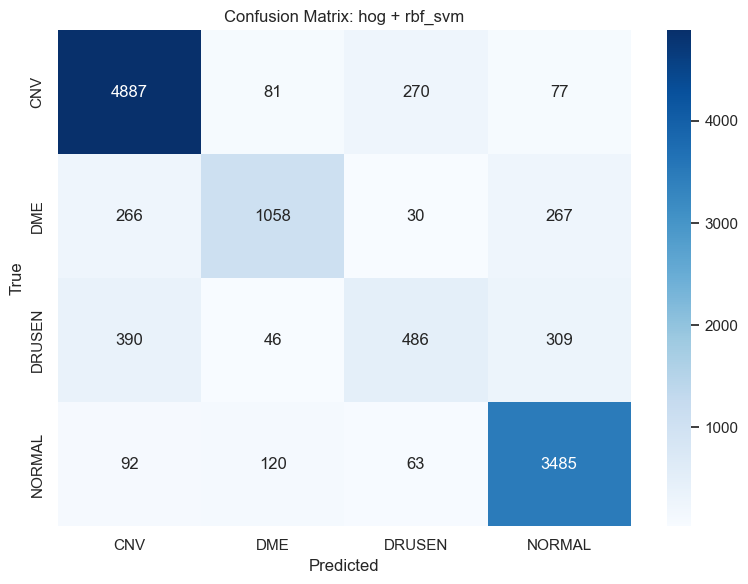

In [9]:
# Confusion matrix (from saved predictions)
y_true = pred_df['y_true'].to_numpy()
y_pred = pred_df['y_pred'].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix: {feature_name} + {classifier_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


In [10]:
# Rebuild feature matrix for ROC / AUC

def compute_feature_matrix(filepaths: list[str], feature: str, image_size_xy: tuple[int, int], sift_k: int = 128) -> np.ndarray:
    feature = feature.lower()

    if feature == 'sift_bovw':
        codebook_path = PROJECT_ROOT / f'data/interim/features/sift_bovw_codebook_k{sift_k}.joblib'
        if not codebook_path.exists():
            raise FileNotFoundError(f'SIFT codebook not found: {codebook_path}')
        extractor = SIFTBOVWExtractor.load(codebook_path)
        return extractor.transform(filepaths)

    vectors = []
    for p in filepaths:
        img = preprocess_for_features(p, size=image_size_xy, normalize=False)
        if feature == 'hog':
            vec = extract_hog_vector(img)
        elif feature == 'lbp':
            vec = extract_lbp_histogram(img)
        else:
            raise ValueError(f'Unsupported feature for this notebook: {feature}')
        vectors.append(vec)
    return np.vstack(vectors)


def scores_from_model(model, X: np.ndarray, class_order: list[str]) -> np.ndarray:
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)
        classes = list(getattr(model, 'classes_', class_order))
        if classes == class_order:
            return probs
        idx_map = [classes.index(c) for c in class_order]
        return probs[:, idx_map]

    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        if scores.shape[1] != len(class_order):
            raise ValueError(f'Unexpected decision_function shape: {scores.shape}')
        scores = scores - scores.max(axis=1, keepdims=True)
        probs = np.exp(scores)
        probs /= probs.sum(axis=1, keepdims=True) + 1e-12
        return probs

    raise ValueError('Model has neither predict_proba nor decision_function.')

model_path = Path(result_df.loc[0, 'model_path'])
if not model_path.exists():
    model_path = MODELS_DIR / 'model.joblib'
model = joblib.load(model_path)

filepaths = pred_df['filepath'].tolist()
X_eval = compute_feature_matrix(filepaths, feature_name, image_size, sift_k=sift_vocab_size)
prob_mat = scores_from_model(model, X_eval, CLASS_NAMES)

print('X_eval shape  =', X_eval.shape)
print('prob_mat shape=', prob_mat.shape)


X_eval shape  = (11927, 6084)
prob_mat shape= (11927, 4)


Macro ROC-AUC (OVR): 0.9445


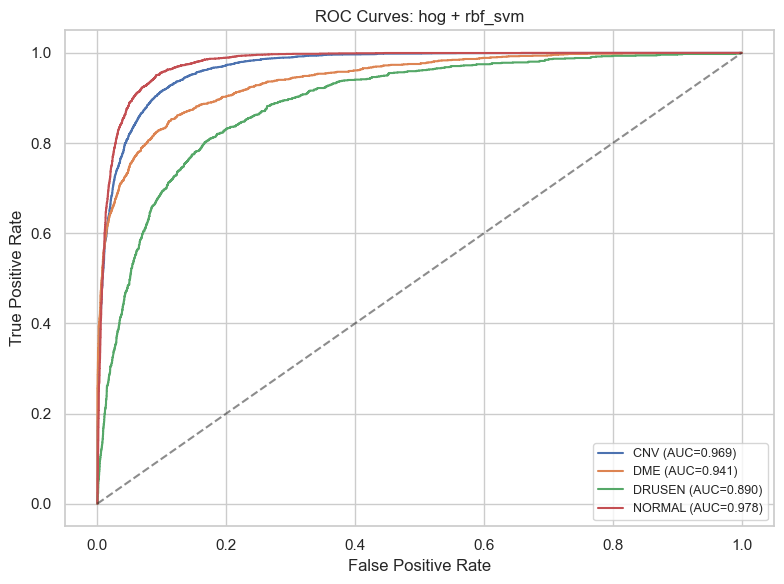

In [11]:
# Multi-class ROC (one-vs-rest)
y_true_bin = label_binarize(y_true, classes=CLASS_NAMES)

auc_macro = roc_auc_score(y_true_bin, prob_mat, average='macro', multi_class='ovr')
print(f'Macro ROC-AUC (OVR): {auc_macro:.4f}')

plt.figure(figsize=(8, 6))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], prob_mat[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves: {feature_name} + {classifier_name}')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## Local Explanation 1: HOG + Linear SVM Coefficient Map

Only available when the classifier is linear SVM with `coef_`.


In [12]:
def hog_linear_explanation_map(img_gray: np.ndarray, svm_model, target_class: str,
                               orientations: int = 9,
                               pixels_per_cell: tuple[int, int] = (16, 16),
                               cells_per_block: tuple[int, int] = (2, 2)) -> np.ndarray:
    if not hasattr(svm_model, 'coef_'):
        raise ValueError('Linear coefficient map requires a linear model with coef_.')

    hog_tensor = hog(
        img_gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=False,
    )

    classes = list(svm_model.classes_)
    cls_idx = classes.index(target_class)
    w = svm_model.coef_[cls_idx].reshape(hog_tensor.shape)

    # Block-level contribution -> cell-level map
    block_contrib = np.abs(hog_tensor * w).sum(axis=-1)
    n_br, n_bc, cbr, cbc = block_contrib.shape

    cell_map = np.zeros((n_br + cbr - 1, n_bc + cbc - 1), dtype=np.float32)
    norm_map = np.zeros_like(cell_map)

    for br in range(n_br):
        for bc in range(n_bc):
            for i in range(cbr):
                for j in range(cbc):
                    cell_map[br + i, bc + j] += block_contrib[br, bc, i, j]
                    norm_map[br + i, bc + j] += 1.0

    cell_map /= np.maximum(norm_map, 1e-6)
    heat = resize(cell_map, img_gray.shape, order=1, preserve_range=True, anti_aliasing=True)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return heat

if feature_name == 'hog' and classifier_name == 'linear_svm' and hasattr(model, 'coef_'):
    candidate = pred_df.loc[~pred_df['is_correct']].head(1)
    if candidate.empty:
        candidate = pred_df.head(1)

    sample_path = candidate.iloc[0]['filepath']
    sample_true = candidate.iloc[0]['y_true']
    sample_pred = candidate.iloc[0]['y_pred']

    img_gray = preprocess_for_features(sample_path, size=image_size, normalize=False)
    heat = hog_linear_explanation_map(img_gray, model, target_class=sample_pred)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title(f'Original\ntrue={sample_true}, pred={sample_pred}')
    axes[0].axis('off')

    axes[1].imshow(img_gray, cmap='gray', alpha=0.65)
    im = axes[1].imshow(heat, cmap='jet', alpha=0.45)
    axes[1].set_title('HOG + LinearSVM coefficient attribution')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('Skip HOG-linear explanation: current run is not hog+linear_svm.')


Skip HOG-linear explanation: current run is not hog+linear_svm.


## Local Explanation 2: Occlusion Sensitivity (Model-agnostic)

Works for HOG/LBP/SIFT traditional models. It highlights patches whose removal causes the largest confidence drop for the predicted class.


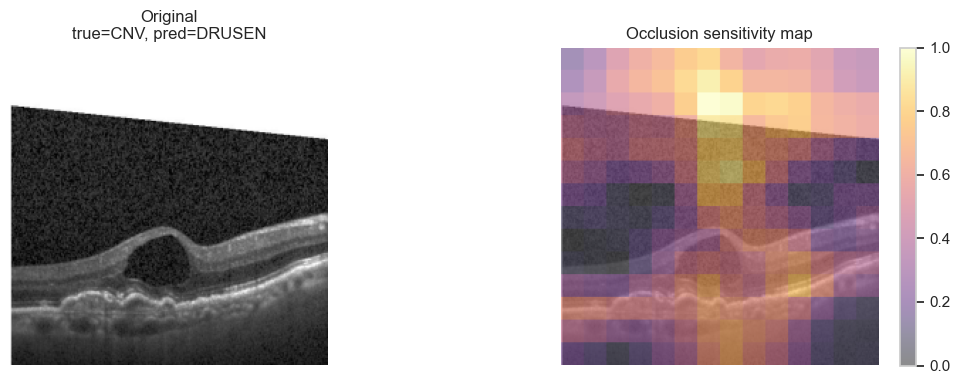

In [13]:
def extract_feature_single(img_gray: np.ndarray, feature: str) -> np.ndarray:
    feature = feature.lower()
    if feature == 'hog':
        return extract_hog_vector(img_gray)
    if feature == 'lbp':
        return extract_lbp_histogram(img_gray)
    if feature == 'sift_bovw':
        raise NotImplementedError(
            'Occlusion for SIFT-BoVW is omitted in this notebook because the extractor expects path-based transform. '
            'Use HOG/LBP runs for local occlusion maps.'
        )
    raise ValueError(f'Unsupported feature: {feature}')


def score_for_class(model, feat_vec: np.ndarray, class_name: str) -> float:
    feat_vec = feat_vec.reshape(1, -1)
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(feat_vec)[0]
        idx = list(model.classes_).index(class_name)
        return float(probs[idx])
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(feat_vec)
        if scores.ndim == 1:
            return float(scores[0])
        idx = list(model.classes_).index(class_name)
        return float(scores[0, idx])
    raise ValueError('Model has no scoring interface.')


def occlusion_map_traditional(img_gray: np.ndarray, model, feature: str, target_class: str,
                              patch: int = 32, stride: int = 16) -> np.ndarray:
    base_feat = extract_feature_single(img_gray, feature=feature)
    base_score = score_for_class(model, base_feat, target_class)

    h, w = img_gray.shape
    heat = np.zeros((h, w), dtype=np.float32)
    cnt = np.zeros((h, w), dtype=np.float32)

    fill_value = int(np.mean(img_gray))
    for y in range(0, h - patch + 1, stride):
        for x in range(0, w - patch + 1, stride):
            occluded = img_gray.copy()
            occluded[y:y+patch, x:x+patch] = fill_value
            feat = extract_feature_single(occluded, feature=feature)
            s = score_for_class(model, feat, target_class)
            drop = max(0.0, base_score - s)
            heat[y:y+patch, x:x+patch] += drop
            cnt[y:y+patch, x:x+patch] += 1

    heat /= np.maximum(cnt, 1e-6)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return heat

if feature_name in ('hog', 'lbp'):
    row = pred_df.loc[~pred_df['is_correct']].head(1)
    if row.empty:
        row = pred_df.head(1)

    sample_path = row.iloc[0]['filepath']
    sample_true = row.iloc[0]['y_true']
    sample_pred = row.iloc[0]['y_pred']
    img_gray = preprocess_for_features(sample_path, size=image_size, normalize=False)

    heat_occ = occlusion_map_traditional(
        img_gray=img_gray,
        model=model,
        feature=feature_name,
        target_class=sample_pred,
        patch=32,
        stride=16,
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title(f'Original\ntrue={sample_true}, pred={sample_pred}')
    axes[0].axis('off')

    axes[1].imshow(img_gray, cmap='gray', alpha=0.65)
    im = axes[1].imshow(heat_occ, cmap='inferno', alpha=0.45)
    axes[1].set_title('Occlusion sensitivity map')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('Skip occlusion map: current run is sift_bovw.')
